# Clustering Homework
Assignment Details: please read the [chapter 6](file:///Users/maisadwal/Downloads/Data_Science_for_Business_What_You_Need_to_Know_ab..._----_(Chapter%C2%A06.%C2%A0Similarity,_Neighbors,_and_Clusters).pdf) from Foster's Data Science for Business and focus on the "Clustering" section.  Your goal is to use scikit learn to mimic the whiskey clustering problem using the associated dataset attached below.  You should start a new colab notebook and add appropriate text to help orient the reader.  Prepare and cluster the data using KMeans and a hierarchical clustering algorithm.  Be sure to interpret the clusters and explain your findings.  Your submission should be a colab notebook with your write up and code.

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
#scikit learn is library for ML in python

Loading & Preprocessing the Data

In [50]:
path = '/content/scotch_data.csv'
whiskey = pd.read_csv(path)

In [51]:
#Row 0 contains the feature labels; I want to use THOSE as column names
col_names = whiskey.iloc[0]
whiskey.columns = col_names

#Now drop the label row, and the two name columns (NAME and the duplicate)
whiskey = whiskey.iloc[1:, 2:].reset_index(drop=True)

#Keep only taste columns (everything before DISTRICT)
taste_cols = whiskey.columns[:68]  # color, NOSE, BODY, PAL, FIN columns
X = whiskey[taste_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

In [52]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [53]:
whiskey.columns

Index(['wyne', 'yellow', 'v.pale', 'pale', 'p.gold', 'gold', 'o.gold',
       'f.gold', 'bronze', 'p.amber', 'amber', 'f.amber', 'red', 'sherry',
       'AROMA', 'PEAT', 'SWEET', 'LIGHT', 'FRESH', 'DRY', 'FRUIT', 'GRASS',
       'SEA', 'SHERRY', 'SPICY', 'RICH', 'soft', 'med', 'full', 'round',
       'smooth', 'light', 'firm', 'oily', 'full', 'dry', 'sherry', 'big',
       'light', 'smooth', 'clean', 'fruit', 'grass', 'smoke', 'sweet', 'spice',
       'oil', 'salt', 'arome', 'full', 'dry', 'warm', 'big', 'light', 'smooth',
       'clean', 'fruit', 'grass', 'smoke', 'sweet', 'spice', 'oil', 'salt',
       'arome', 'ling', 'long', 'very', 'quick', 'AGE', 'DIST', 'SCORE', '%',
       'REGION', 'DISTRICT', 'islay', 'midland', 'spey', 'east', 'west',
       'north ', 'lowland', 'campbell', 'islands'],
      dtype='object', name=0)

In [54]:
whiskey.shape

(111, 83)

KMeans Clustering

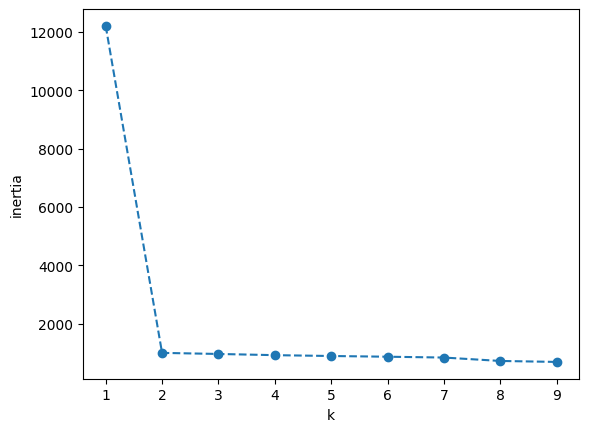

In [55]:
#to find the optimal number of clusters (elbow method)
inertia = []
k_values = range(1, 10)

for k in k_values:
  km = KMeans(n_clusters = k, random_state=52)
  km.fit(X_scaled)
  inertia.append(km.inertia_)
plt.plot(k_values, inertia, '--o')
plt.xlabel('k')
plt.ylabel('inertia')
plt.show()

In [56]:
#setting the ideal # of clusters for KMeans clustering
kmeans = KMeans(n_clusters = 2).fit(X_scaled)
kmeans

KMeans(n_clusters=2)

In [57]:
#where the learned cluster centers are
#ach number is the average value of one binary feature across all whiskeys in that cluster.
#since every feature is either 0 or 1, the average tells you the proportion of whiskeys in that cluster that have that trait
kmeans.cluster_centers_

array([[-0.09012921, -0.0777333 , -0.0777333 , -0.08536295, -0.09118195,
        -0.09351291, -0.0777333 , -0.09400589, -0.08717713, -0.08536295,
        -0.09264475, -0.08536295, -0.08536295, -0.06711283, -0.09118195,
        -0.09460542, -0.09487083, -0.09470935, -0.09243146, -0.09328208,
        -0.0945134 , -0.09427881, -0.09406806, -0.09351291, -0.09412606,
        -0.08717713, -0.09299929, -0.09351291, -0.09506169, -0.09386707,
        -0.09299929, -0.08939919, -0.09218718, -0.09468511, -0.09218718,
        -0.09190462, -0.0948877 , -0.09243146, -0.09070953, -0.09406806,
        -0.09314822, -0.09386707, -0.09299929, -0.08939919, -0.09465976,
        -0.09460542, -0.06711283, -0.09118195, -0.08939919, -0.09264475,
        -0.0948877 , -0.09243146, -0.09070953, -0.09468511, -0.09218718,
        -0.09190462, -0.09264475, -0.09012921, -0.09454561, -0.09190462,
        -0.09340305, -0.09070953, -0.09427881, -0.09351291, -0.09519454,
        -0.09314822, -0.09370489, -0.09243146, -0.0

In [62]:
#i dont like looking at it as it is in the previous block ^
#so now this is a more readable version
feature_names = X.columns.tolist()
centers_df = pd.DataFrame(kmeans.cluster_centers_, columns=feature_names)
print(centers_df.round(2).T)

           0      1
wyne   -0.09   9.91
yellow -0.08   8.55
v.pale -0.08   8.55
pale   -0.09   9.39
p.gold -0.09  10.03
...      ...    ...
arome  -0.09   9.83
ling   -0.09  10.07
long   -0.09  10.32
very   -0.09   9.39
quick  -0.09   9.73

[110 rows x 2 columns]


In [65]:
#i also searched up how to interpret centers using the ORIGINAL unscaled data
centers_original = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=X.columns
)
print(centers_original.round(2).T)

           0     1
0                 
wyne    0.07   8.0
yellow  0.02   2.0
v.pale  0.02   2.0
pale    0.04   4.0
p.gold  0.09  10.0
...      ...   ...
arome   0.06   7.0
ling    0.10  11.0
long    0.22  24.0
very    0.04   4.0
quick   0.05   6.0

[110 rows x 2 columns]


In [59]:
dbscan = DBSCAN(eps = 1).fit(X)
dbscan.labels_
#all the negative numbers are not part of a cluster
#essentially DBSCAN found zero clusters
#i know DBSCAN isn't required nor suitable for this data, but I just wanted to include it for practice

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1])

Hierarchical Clustering

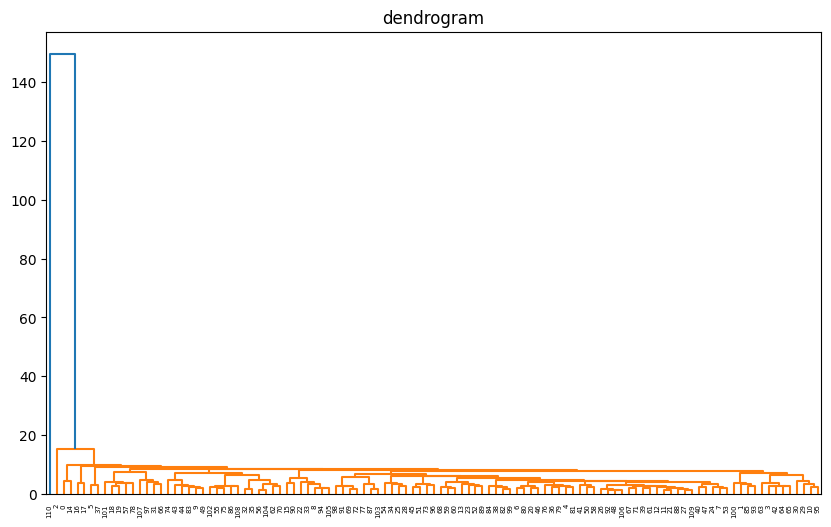

In [60]:
#Hierarchical clusters
from scipy.cluster.hierarchy import linkage, dendrogram

#create linkage matrix
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,6))
dendrogram(linked) #a dendrogram shows explicitly the hierarchy of the structure
plt.title('dendrogram')
plt.show()